In [16]:
#import
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go



In [17]:
# ------------------------------
# HYPERPARAMETERS & SETTINGS
# ------------------------------

# Model & Training Config
FEATURES = [
     "observations"
]
HIDDEN_LAYERS = [64, 32]  # Increase model complexity with more layers
ACTIVATION = nn.ReLU
DROPOUT = 0.1  # Increase dropout rate to reduce overfitting
LOSS_FN = nn.MSELoss
OPTIMIZER_FN = optim.Adam
LEARNING_RATE = 0.0001  # Reduce learning rate for more stable training
WEIGHT_DECAY = 0.0001  # Increase weight decay for regularization
EPOCHS = 6000  # Reduce epochs to prevent overfitting
BATCH_SIZE = 32  # Increase batch size for faster training
SEED = 42
TEST_SIZE = 0.2
N_SAMPLES = 1000  # Simulate data for 30 days
BEST_LOSS = float('inf')  # Start with a very high loss
PATIENCE = 100  # Reduce patience to stop earlier if no improvement
PATIENCE_COUNTER = 0 # Counter for early stopping
LAG_DAYS = 10


In [18]:
# Set a random seed for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# Create a date range starting from January 1, 2025
dates = pd.date_range(start="2025-01-01", periods=N_SAMPLES, freq="D")

# Generate random observations between 20 and 200
observations = np.random.randint(20, 200, size=N_SAMPLES)

# Add some noise to the observations
trend = np.linspace(50, 150, N_SAMPLES)
seasonality = 30 * np.sin(np.linspace(0, 6*np.pi, N_SAMPLES))
noise = np.random.normal(0, 5, N_SAMPLES)
observations = trend + seasonality + noise

# Create the DataFrame
df = pd.DataFrame({
    "dates": dates,
    "observations": observations
})

# Function to create lag features
def create_lag_features(df, target_column, lag_days):
    for lag in range(1, lag_days + 1):
        df[f"lag_{lag}"] = df[target_column].shift(lag)
    return df

# Apply the function to create lag features
df = create_lag_features(df, "observations", LAG_DAYS)

# Drop rows with NaN values caused by lagging
df.dropna(inplace=True)

# Visualization
fig = go.Figure()
fig.add_trace(go.Scatter(x=dates[:200], y=observations[:200], mode='lines', name='Observations', opacity=0.7))

fig.update_layout(
    title="Observations Over Time",
    xaxis_title="Date",
    yaxis_title="Observations",
    legend_title="Legend",
    template="plotly_white"
)

fig.show()

In [19]:
df.head(40)

,dates,observations,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
10,2025-01-11,55.257779,49.515304,58.579044,56.945110,51.777505,56.516401,56.476699,54.484011,54.228554,49.720081,53.340505
11,2025-01-12,60.323642,55.257779,49.515304,58.579044,56.945110,51.777505,56.516401,56.476699,54.484011,54.228554,49.720081
12,2025-01-13,66.482406,60.323642,55.257779,49.515304,58.579044,56.945110,51.777505,56.516401,56.476699,54.484011,54.228554
13,2025-01-14,62.710918,66.482406,60.323642,55.257779,49.515304,58.579044,56.945110,51.777505,56.516401,56.476699,54.484011
14,2025-01-15,68.096187,62.710918,66.482406,60.323642,55.257779,49.515304,58.579044,56.945110,51.777505,56.516401,56.476699
15,2025-01-16,57.887521,68.096187,62.710918,66.482406,60.323642,55.257779,49.515304,58.579044,56.945110,51.777505,56.516401
16,2025-01-17,61.772449,57.887521,68.096187,62.710918,66.482406,60.323642,55.257779,49.515304,58.579044,56.945110,51.777505
17,2025-01-18,65.189106,61.772449,57.887521,68.096187,62.710918,66.482406,60.323642,55.257779,49.515304,58.579044,56.945110
18,2025-01-19,50.164237,65.189106,61.772449,57.887521,68.096187,62.710918,66.482406,60.323642,55.257779,49.515304,58.579044
19,2025-01-20,69.982020,50.164237,65.189106,61.772449,57.887521,68.096187,62.710918,66.482406,60.323642,55.257779,49.515304


In [20]:
# Ensure MinMaxScaler is imported
from sklearn.preprocessing import MinMaxScaler

def create_sequences(df, target_column, sequence_length):
    data = df.values
    target_idx = df.columns.get_loc(target_column)

    sequences = []
    targets = []
    for i in range(len(df) - sequence_length):
        seq = data[i:i + sequence_length]
        target = data[i + sequence_length, target_idx]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

# ----------------------------
# LSTM Preprocessing for Sequences
# ----------------------------
def preprocess_lstm_sequences(df, features, target_column, batch_size, sequence_length, test_size=0.2, scale=True, target_scaler=True):
    feature_scaler = None
    target_scaler = None
    
    if scale:
        if target_column in features:
            feature_scaler = target_scaler = MinMaxScaler()
            df[target_column] = target_scaler.fit_transform(df[[target_column]])
        else:
            feature_scaler = MinMaxScaler()
            target_scaler = MinMaxScaler()
            df[features] = feature_scaler.fit_transform(df[features])
            df[target_column] = target_scaler.fit_transform(df[[target_column]])
    
    used_cols = features if target_column in features else features + [target_column]


    X, y = create_sequences(df[used_cols], target_column, sequence_length)

    print("X.shape after sequence creation:", X.shape)
    print(y)
    # Split AFTER sequence creation
    split_index = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    # Reshape for LSTM: (samples, sequence_length, num_features)
    num_features = X.shape[2] if len(X.shape) > 2 else len(features)
    X_train = X_train.reshape(-1, sequence_length, num_features)
    X_test = X_test.reshape(-1, sequence_length, num_features)

    # Convert to tensors
    X_tensor = torch.from_numpy(X_train).float()
    y_tensor = torch.from_numpy(y_train).float().unsqueeze(1)
    X_test = torch.from_numpy(X_test).float()
    y_test = torch.from_numpy(y_test).float().unsqueeze(1)

    # Create DataLoader
    train_dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, X_test, y_test, X_tensor, y_tensor, feature_scaler, target_scaler

# ----------------------------
# Call Preprocessing
# ----------------------------
sequence_length = LAG_DAYS
FEATURES = ["observations"]

train_loader, X_test, y_test, X_tensor, y_tensor, feature_scaler, target_scaler = preprocess_lstm_sequences(
    df=df,
    features=FEATURES,
    target_column="observations",
    batch_size=BATCH_SIZE,
    sequence_length=LAG_DAYS,
    test_size=TEST_SIZE,
    scale=True,
)


X.shape after sequence creation: (980, 10, 1)
[0.16209621 0.27108439 0.26428549 0.15820111 0.16451568 0.30493457
 0.30137617 0.22916537 0.23345196 0.28869064 0.27373815 0.31693322
 0.30008833 0.34452277 0.32619446 0.32110712 0.28587787 0.28712861
 0.3046537  0.37763676 0.29929506 0.32737803 0.23949686 0.34982368
 0.41115882 0.29805958 0.45160361 0.34564433 0.2482856  0.3314664
 0.39735938 0.42492828 0.38117673 0.41521647 0.31783402 0.33888059
 0.30516983 0.34716008 0.39977272 0.38229655 0.4087611  0.34528299
 0.34989343 0.39167154 0.36441202 0.43616686 0.36776275 0.37460434
 0.40995302 0.38229209 0.35318462 0.35985614 0.42131759 0.3535853
 0.45577305 0.38090501 0.42998291 0.38568816 0.37645998 0.41999723
 0.45046069 0.40393587 0.41145023 0.44413581 0.44605766 0.41457234
 0.40033007 0.42003306 0.41043709 0.42917146 0.37434169 0.42827585
 0.3919911  0.45135213 0.39361562 0.3941099  0.43410629 0.41805883
 0.50036085 0.35719518 0.42022675 0.45689882 0.39382504 0.38094672
 0.38158626 0.3536

In [21]:
print("FEATURES:", FEATURES)


FEATURES: ['observations']


In [22]:
print("Raw X_train shape:", X_tensor.shape)
print("Expected reshape size:", (X_tensor.shape[0], sequence_length, len(FEATURES)))


Raw X_train shape: torch.Size([784, 10, 1])
Expected reshape size: (784, 10, 1)


In [23]:
X_test.shape, y_test.shape, X_tensor.shape, y_tensor.shape

(torch.Size([196, 10, 1]),
 torch.Size([196, 1]),
 torch.Size([784, 10, 1]),
 torch.Size([784, 1]))

In [24]:
# ----------------------------
# Customizable LSTM
# Model
# ----------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)  # Only use the hidden state from the last time step
        out = self.fc(hidden[-1])  # Pass the last hidden state through a fully connected layer
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check if cuda is available and use it if it is available otherwise use cpu


model = LSTMModel(
    input_size=len(FEATURES),  # input dimension is the number of features
    hidden_size=HIDDEN_LAYERS[0],  # use the first hidden layer size as the hidden size
    output_size=1,  # output size is 1 since we are predicting a single value
    num_layers=len(HIDDEN_LAYERS)  # number of layers is the length of HIDDEN_LAYERS
).to(device)

model

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [25]:
# ----------------------------
# Loss & Optimizer
# ----------------------------
loss_fn = LOSS_FN() # create the loss function using the loss function specified in the hyperparameters
optimizer = OPTIMIZER_FN(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # create the optimizer using the optimizer specified in the hyperparameters

Epoch 000 | Train Loss: 0.3344 | Test Loss: 0.5215
Epoch 100 | Train Loss: 0.0020 | Test Loss: 0.0018
Epoch 200 | Train Loss: 0.0020 | Test Loss: 0.0019
Epoch 300 | Train Loss: 0.0019 | Test Loss: 0.0022
Epoch 400 | Train Loss: 0.0021 | Test Loss: 0.0017
Epoch 500 | Train Loss: 0.0019 | Test Loss: 0.0019
Epoch 600 | Train Loss: 0.0019 | Test Loss: 0.0018
Epoch 700 | Train Loss: 0.0019 | Test Loss: 0.0017
Epoch 800 | Train Loss: 0.0019 | Test Loss: 0.0016
Epoch 900 | Train Loss: 0.0019 | Test Loss: 0.0018
Epoch 1000 | Train Loss: 0.0019 | Test Loss: 0.0018
Epoch 1100 | Train Loss: 0.0019 | Test Loss: 0.0017
Epoch 1200 | Train Loss: 0.0019 | Test Loss: 0.0017
Epoch 1300 | Train Loss: 0.0019 | Test Loss: 0.0016
Epoch 1400 | Train Loss: 0.0019 | Test Loss: 0.0017
Epoch 1500 | Train Loss: 0.0019 | Test Loss: 0.0016
Epoch 1600 | Train Loss: 0.0019 | Test Loss: 0.0017
Epoch 1700 | Train Loss: 0.0020 | Test Loss: 0.0017
Epoch 1800 | Train Loss: 0.0019 | Test Loss: 0.0016
Epoch 1900 | Train Los

/Users/jaytlinaskew/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning:

Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.



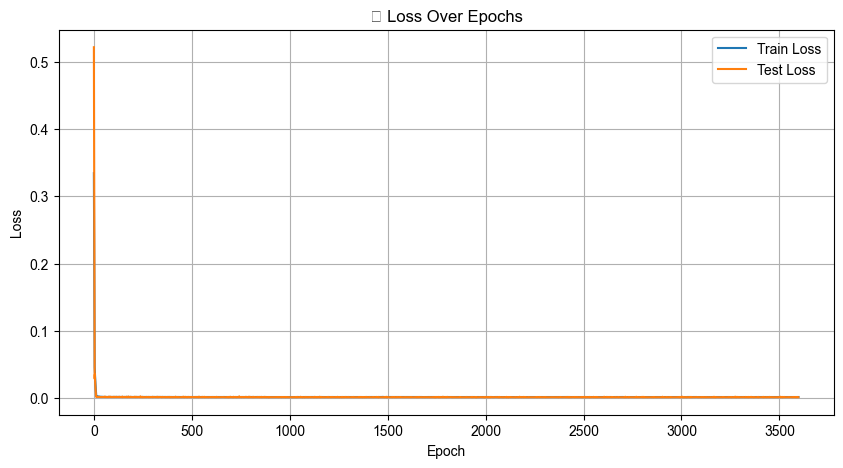

In [ ]:
# ----------------------------
# Training Loop + Evaluation
# ----------------------------

train_losses = []
test_losses = []

BEST_LOSS = float("inf")
PATIENCE_COUNTER = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Reshape input to match LSTM expected input shape: (batch_size, sequence_length, input_size)
        # Ensure input shape matches LSTM expected input shape: (batch_size, sequence_length, input_size)
        # No need to unsqueeze here as the input is already in the correct shape

        preds = model(xb)  # should be shape: (batch_size, 1)

        # Ensure both preds and yb have the same shape
        if preds.ndim == 1:
            preds = preds.unsqueeze(1)  
        if yb.ndim == 1:
            yb = yb.unsqueeze(1)  

        loss = loss_fn(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Average training loss
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ----------------------
    # Evaluate on Test Data
    # ----------------------
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test.to(device))
        test_loss = loss_fn(y_pred_test, y_test.to(device)).item()
        test_losses.append(test_loss)

        # Early Stopping Logic
        if test_loss < BEST_LOSS:
            BEST_LOSS = test_loss
            PATIENCE_COUNTER = 0
            best_model_state = model.state_dict()
        else:
            PATIENCE_COUNTER += 1

        if PATIENCE_COUNTER >= PATIENCE:
            print(f"Early stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.")
            break

    # Logging
    if epoch % 100 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

# Load the best model state after training
model.load_state_dict(best_model_state)

# ----------------------------
# Plot Loss Curve
# ----------------------------
plt.rcParams['font.family'] = 'Arial'  # Set font family before plotting
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("📉 Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device)).cpu().numpy()
    y_true = y_test.cpu().numpy()
    y_pred = target_scaler.inverse_transform(y_pred)
    y_true = target_scaler.inverse_transform(y_true)

In [28]:
def forecast(model, initial_sequence, steps):
    model.eval()
    predictions = []
    current_sequence = initial_sequence.clone()

    for _ in range(steps):
        with torch.no_grad():
            # Reshape to (1, sequence_length, 1)
            pred = model(current_sequence.unsqueeze(0).unsqueeze(-1)).item()
            predictions.append(pred)
            # Update sequence: drop oldest, append new pred
            current_sequence = torch.cat((current_sequence[1:], torch.tensor([pred], dtype=current_sequence.dtype)))
    
    return predictions

# Use last known sequence from test set
initial_sequence = X_test[-1].squeeze()  # shape: (LAG_DAYS,)
future_predictions = forecast(model, initial_sequence, steps=10)
future_predictions = target_scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
).flatten()



In [29]:
print("y_pred shape:", y_pred.shape)
print("Sample predictions:", y_pred[:5].flatten())

# Get the last date in your dataset
last_date = df["dates"].max()

#unscale future predictions
future_predictions = target_scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# Create future dates matching forecast steps
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(future_predictions), freq="D")

# Get last N true points
N = 30
recent_dates = df["dates"].iloc[-N:]
recent_values = target_scaler.inverse_transform(y_test.cpu().numpy())[-N:]  # if scaled

# Combine with forecast
fig = go.Figure()
fig.add_trace(go.Scatter(x=recent_dates, y=recent_values.flatten(), mode='lines', name='Recent Observations'))
fig.add_trace(go.Scatter(x=future_dates, y=future_predictions, mode='lines+markers', name='Forecast'))

fig.update_layout(
    title="Last Observations + 10-Step Forecast",
    xaxis_title="Date",
    yaxis_title="Observations",
    template="plotly_white"
)
fig.show()



y_pred shape: (196, 1)
Sample predictions: [147.50789 147.54579 147.41878 147.60622 147.92963]


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [30]:
# actual vs predicted
# Ensure all arrays have the same length
min_length = min(len(recent_dates), len(recent_values.flatten()), len(future_dates), len(future_predictions))

data = pd.DataFrame({
	"recent_dates": recent_dates[-min_length:],  # Trim to match the minimum length
	"recent_values": recent_values.flatten()[-min_length:],  # Trim to match the minimum length
	"future_dates": future_dates[:min_length],  # Trim to match the minimum length
	"future_predictions": future_predictions[:min_length]  # Trim to match the minimum length
})
print(data.head(10))

    recent_dates  recent_values future_dates  future_predictions
990   2027-09-18     146.754684   2027-09-28        20570.347585
991   2027-09-19     139.970871   2027-09-29        20561.950402
992   2027-09-20     146.867340   2027-09-30        20583.336210
993   2027-09-21     139.126877   2027-10-01        20625.383506
994   2027-09-22     150.263367   2027-10-02        20638.292891
995   2027-09-23     155.715271   2027-10-03        20679.596896
996   2027-09-24     156.401413   2027-10-04        20678.211874
997   2027-09-25     152.342422   2027-10-05        20661.583801
998   2027-09-26     146.416809   2027-10-06        20647.136495
999   2027-09-27     143.495499   2027-10-07        20649.568374


In [31]:
# Compute average accuracy (1 - MAPE)
accuracy = 1 - np.mean(np.abs((y_true - y_pred) / y_true))
print(f"Average Accuracy: {accuracy:.2%}")

# Compare to previous best accuracy
if 'prev_accuracy' not in locals():
    prev_accuracy = 0  # Initialize prev_accuracy if not already defined

if accuracy > prev_accuracy:
    best_accuracy = accuracy
    print(f"New best accuracy: {best_accuracy:.2%}")
    # Update stored accuracy
    prev_accuracy = accuracy
else:
    print(f"Accuracy did not improve (Best: {prev_accuracy:.2%})")



# Save the actual and predicted values to a dataframe
pred_df = pd.DataFrame({
    "timestamp": df["dates"].values[:len(y_pred)],
    "actual_observed": y_true.flatten(),
    "predicted_observed": y_pred.flatten()
})

# Add the difference between actual and predicted values
pred_df["difference"] = pred_df["actual_observed"] - pred_df["predicted_observed"]

#print the first 10 rows of the dataframe
pred_df.head(10)

Average Accuracy: 96.51%
New best accuracy: 96.51%


,timestamp,actual_observed,predicted_observed,difference
0,2025-01-11,150.599304,147.507889,3.091415
1,2025-01-12,147.584503,147.545792,0.038712
2,2025-01-13,149.449188,147.418777,2.030411
3,2025-01-14,148.032440,147.606216,0.426224
4,2025-01-15,152.833115,147.929626,4.903488
5,2025-01-16,138.554657,148.374222,-9.819565
6,2025-01-17,145.339920,147.495255,-2.155334
7,2025-01-18,132.151138,147.139633,-14.988495
8,2025-01-19,136.013382,145.445557,-9.432175
9,2025-01-20,141.797775,143.748627,-1.950851


In [32]:
# Define new parameters as a dictionary
new_params = {
    "Hidden Layers": [HIDDEN_LAYERS],
    "Activation Function": [ACTIVATION.__name__],
    "Dropout Rate": [DROPOUT],
    "Loss Function": [LOSS_FN.__name__],
    "Optimizer": [OPTIMIZER_FN.__name__],
    "Learning Rate": [LEARNING_RATE],
    "Weight Decay": [WEIGHT_DECAY],
    "Epochs": [EPOCHS],
    "Batch Size": [BATCH_SIZE],
    "Seed": [SEED],
    "Test Size": [TEST_SIZE],
    "N_Samples": [N_SAMPLES],
    "Best Loss": [BEST_LOSS],
    "Patience": [PATIENCE],
    "Patience Counter": [PATIENCE_COUNTER],
    "Average Accuracy": accuracy,  # Keep as float for sorting
    "Average Accuracy (%)": f"{round(accuracy * 100, 2)}%"  # Display version

}

# Convert the dictionary to a DataFrame
new_params_df = pd.DataFrame(new_params)

# Initialize params as an empty DataFrame if it doesn't exist
if 'params' not in locals():
    params = pd.DataFrame()

# Append the new parameters to the existing DataFrame
params = pd.concat([params, new_params_df], ignore_index=True).sort_values(by="Average Accuracy", ascending=False).reset_index(drop=True)

# Print the updated DataFrame
params

,Hidden Layers,Activation Function,Dropout Rate,Loss Function,Optimizer,Learning Rate,Weight Decay,Epochs,Batch Size,Seed,Test Size,N_Samples,Best Loss,Patience,Patience Counter,Average Accuracy,Average Accuracy (%)
0,"[64, 32]",ReLU,0.1,MSELoss,Adam,0.0001,0.0001,6000,32,42,0.2,1000,0.001578,100,100,0.965099,96.51%


#save the dataframe to a csv file
params.to_csv("/Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/Performance_Data/Neural_Networks/Regression/NextObserved.csv", index=False)